**First save a copy of this notebook in your Google drive.** Read this notebook from top to bottom and fill in the code as you go. Work together with your partner and discuss with other students in the class. Try to resolve any errors on your own first, but don't get stuck; ask for help!

For many of these questions, there are several ways to do it in Pandas. You only need to choose one that works. But you might want to experiment with multiple ways of doing the same thing to get practice working with Pandas.





## Titanic Data

 The Titanic data set (https://raw.githubusercontent.com/kevindavisross/data301/main/data/titanic.csv) contains information about 2206 passengers and crew members that were aboard the RMS Titanic when it sank on April 15, 1912.

1\. Read in the Titanic data set. What seems to be the observational unit?

- survived

In [ ]:
# YOUR CODE HERE - ADD AS MANY CELLS AS YOU WANT
import pandas as pd
titanic = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/main/data/titanic.csv")
titanic.head()

,name,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN


2\. What column seems to be an appropriate index for this data frame? Can you think of any problems with using this column as the index?

name, a problem is if the name is repeated

3\. Regardless of your answer to the previous question, write code to make "name" the index of the data frame.

In [ ]:
# YOUR CODE HERE
titanic = titanic.set_index("name")
titanic.head()


,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew
name,,,,,,,,,,
"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN
"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN
"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN


 4\. Write code that returns the observations for  "Kelly, Mr. James". What do you notice? (You can also try "Green, Mr. George"). Note: you might try this both with "name" as the index and with it not as the index.

In [ ]:
# YOUR CODE HERE
titanic = titanic.reset_index()
titanic[titanic["name"] == "Kelly, Mr. James"]

titanic = titanic.set_index("name")
titanic.loc["Kelly, Mr. James"]


,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew
name,,,,,,,,,,
"Kelly, Mr. James",male,19.0,3rd,S,Scotland,363592.0,8.0100,0,3.0,NaN
"Kelly, Mr. James",male,44.0,3rd,Q,Ireland,330911.0,7.1607,0,3.0,NaN
"Kelly, Mr. James",male,44.0,engineering crew,S,England,NaN,NaN,0,NaN,engineering crew


5\. Write code to extract a single `DataFrame` containing the observations three members of the Widener family:
  - Widener, Mr. George Dunton
  - Widener, Mr. Harry Elkins
  - Widener, Mrs. Eleanor

What became of them? Using a search engine, what else can you learn about them? (Note: you could just provide a list of these names. But you might also want to experiment with functions for working with strings, e.g., [`str.contains`](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.contains.html) to find all instances of "Widener"; in this case, it might be helpful to have name as a regular column and not the index.)

only one of them survived, which is Mrs. Eleanor

In [ ]:
# YOUR CODE HERE
titanic.loc[["Widener, Mr. George Dunton",
            "Widener, Mr. Harry Elkins",
            "Widener, Mrs. Eleanor"]]

,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew
name,,,,,,,,,,
"Widener, Mr. George Dunton",male,50.0,1st,S,United States,113503.0,211.1,0,1.0,NaN
"Widener, Mr. Harry Elkins",male,27.0,1st,S,United States,113503.0,211.1,0,1.0,NaN
"Widener, Mrs. Eleanor",female,50.0,1st,S,United States,113503.0,211.1,1,1.0,NaN


6\. Look at a few rows in the full data set. Try to identify what each variable measures. Also, try to identify each variable as either quantitative, categorical, or other. (In general, there should be a code book with information about all the variables. But try to infer what you can from context.)

gender: categorical male or female
name: text, other identifier
age: quantitative

In [ ]:
# YOUR CODE HERE
titanic.head()
titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2207 entries, Abbing, Mr. Anthony to Zarracchi, Sig. L.
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   gender    2207 non-null   object 
 1   age       2205 non-null   float64
 2   class     2207 non-null   object 
 3   embarked  2207 non-null   object 
 4   country   2126 non-null   object 
 5   ticketno  1316 non-null   float64
 6   fare      1291 non-null   float64
 7   survived  2207 non-null   int64  
 8   pclass    1317 non-null   float64
 9   crew      890 non-null    object 
dtypes: float64(4), int64(1), object(5)
memory usage: 254.2+ KB


7\. The variable `pclass` measures the class for passengers. Why are some of the values in this column `NaN`? Should this variable be categorical or quantitative? What type does Pandas this it is?

- they are NaN since some of theem are crew, so they do not have a passener class
- It should be categorical, since 1 2 3 are the labels for first second and third class
- panda thinks it is float64, which are only digits

In [ ]:
# YOUR CODE HERE
print(titanic["pclass"].isna().sum())
print(titanic[titanic["pclass"].isna()]["class"].value_counts())
print(titanic["pclass"].dtype)


890
class
victualling crew    431
engineering crew    324
restaurant staff     69
deck crew            66
Name: count, dtype: int64
float64


8\. Write code to cast `pclass` to the correct type. Repeat for any other variables that do not have the correct type.

In [ ]:
# YOUR CODE HERE
titanic["pclass"] = pd.Categorical(titanic["pclass"], categories=[1, 2, 3], ordered=True)
titanic["survived"] = pd.Categorical(titanic["survived"], categories=[0,1], ordered=True)
print(titanic["pclass"].dtype)
print(titanic["survived"].dtype)




category
category


## Transforming Categorical Variables

A categorical variable can be transformed by mapping its levels to new levels. For example, we may only be interested in whether a person on the titanic was a passenger or a crew member. The variable `class` is too detailed for these purposes. We can create a new variable, `type`, that is derived from the existing variable `class`. Observations with a `class` of "1st", "2nd", or "3rd" get a value of "passenger", while observations with a `class` of "deck crew", "engineering crew", or "deck crew" get a value of "crew".

In [ ]:
titanic["type"] = titanic["class"].map({
    "1st": "passenger",
    "2nd": "passenger",
    "3rd": "passenger",
    "victualling crew": "crew",
    "engineering crew": "crew",
    "deck crew": "crew"
})

titanic

,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew,type
name,,,,,,,,,,,
"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3,NaN,passenger
"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3,NaN,passenger
"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3,NaN,passenger
"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3,NaN,passenger
"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3,NaN,passenger
...,...,...,...,...,...,...,...,...,...,...,...
"Wynn, Mr. Walter",male,41.0,deck crew,B,England,NaN,NaN,1,NaN,deck crew,crew
"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,NaN,NaN,1,NaN,victualling crew,crew
"Young, Mr. Francis James",male,32.0,engineering crew,S,England,NaN,NaN,0,NaN,engineering crew,crew


Upon closer inspection of this `DataFrame`, we see that we accidentally left out the level "restaurant staff" in the input to `.map()`. Any levels that are unspecified will be mapped to the missing value `NaN`.

This suggests a more concise way to define the new variable `type`. We can specify only the levels for passengers in the mapping and then fill in the missing values afterwards.

In [ ]:
titanic["type"] = titanic["class"].map({
    "1st": "passenger",
    "2nd": "passenger",
    "3rd": "passenger"
})

# Replace all missing values by "crew"
titanic["type"].fillna("crew", inplace=True)

titanic

/tmp/ipykernel_6456/651863585.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic["type"].fillna("crew", inplace=True)


,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew,type
name,,,,,,,,,,,
"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3,NaN,passenger
"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3,NaN,passenger
"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3,NaN,passenger
"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3,NaN,passenger
"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3,NaN,passenger
...,...,...,...,...,...,...,...,...,...,...,...
"Wynn, Mr. Walter",male,41.0,deck crew,B,England,NaN,NaN,1,NaN,deck crew,crew
"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,NaN,NaN,1,NaN,victualling crew,crew
"Young, Mr. Francis James",male,32.0,engineering crew,S,England,NaN,NaN,0,NaN,engineering crew,crew


For more complex mappings, the `.map()` method also accepts a function. So the above is equivalent to

In [ ]:
def class_to_type(c):
  if c in ["1st", "2nd", "3rd"]:
    return "passenger"
  else:
    return "crew"

titanic["class"].map(class_to_type)

,class
name,
"Abbing, Mr. Anthony",passenger
"Abbott, Mr. Eugene Joseph",passenger
"Abbott, Mr. Rossmore Edward",passenger
"Abbott, Mrs. Rhoda Mary 'Rosa'",passenger
"Abelseth, Miss. Karen Marie",passenger
...,...
"Wynn, Mr. Walter",crew
"Yearsley, Mr. Harry",crew
"Young, Mr. Francis James",crew


## Converting Quantitative Variables to Categorical Variables

Sometimes it is necessary to categorize quantitative variables. We can use the `cut` function in `pandas` to categorize or bin a quantitative variable, by specifying the endpoints of the bins. We can also provide labels for the bins.

In [ ]:
titanic["age_categories"] = pd.cut(x = titanic["age"],
                                      bins = [0, 18, 30, 45, 65, 130],
                                      labels = ["<18", "18-30", "30-45", "45-65", "65+"])

titanic

,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew,type,age_categories
name,,,,,,,,,,,,
"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3,NaN,passenger,30-45
"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3,NaN,passenger,<18
"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3,NaN,passenger,<18
"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3,NaN,passenger,30-45
"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3,NaN,passenger,<18
...,...,...,...,...,...,...,...,...,...,...,...,...
"Wynn, Mr. Walter",male,41.0,deck crew,B,England,NaN,NaN,1,NaN,deck crew,crew,30-45
"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,NaN,NaN,1,NaN,victualling crew,crew,30-45
"Young, Mr. Francis James",male,32.0,engineering crew,S,England,NaN,NaN,0,NaN,engineering crew,crew,30-45


Now we can treat the new variable as we would any other categorical variable.

In [ ]:
titanic["age_categories"]

,age_categories
name,
"Abbing, Mr. Anthony",30-45
"Abbott, Mr. Eugene Joseph",<18
"Abbott, Mr. Rossmore Edward",<18
"Abbott, Mrs. Rhoda Mary 'Rosa'",30-45
"Abelseth, Miss. Karen Marie",<18
...,...
"Wynn, Mr. Walter",30-45
"Yearsley, Mr. Harry",30-45
"Young, Mr. Francis James",30-45


Arguments to the `cut` method can be specified to determine the treatment of the bin endpoints, but we won't go into the details here. There is also a `qcut` method which creates bins based on quantiles (e.g., the endpoints are the 25th, 50th, and 75th percentiles (along with the min and max).)

## Back to the Exercises about the Titanic data...

10\. Create a new country column that contains only the values United States, United Kingdom, or Other. (At the time of the Titanic, the countries in the United Kingdom were England, Scotland, Wales, and Ireland, including what is now Northern Ireland.) Don't overwrite the original country column.

In [ ]:
# YOUR CODE HERE
titanic["new_country"] = titanic["country"].map({
    "United States":"United States",
    "England":"United Kingdom",
    "Scotland":"United Kingdom",
    "Wales":"United Kingdom",
    "Ireland":"United Kingdom",
    "Northern Ireland": "United Kingdom"
}).fillna("Other")

titanic["new_country"].value_counts()


,count
new_country,
United Kingdom,1339
Other,604
United States,264


11\. Create a new column that categorizes the fare variable into bins of length 5 from 0 to 25, bins of length 25 from 25 to 100, and 100+.

In [ ]:
# YOUR CODE HERE
import numpy as np




titanic["fare_categories"] = pd.cut(x = titanic["fare"],
                                      bins = [0, 5,10, 15, 20, 25, 50, 75, 100, np.inf])

titanic

,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew,type,age_categories,new_country,fare_categories
name,,,,,,,,,,,,,,
"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3,NaN,passenger,30-45,United States,"(5.0, 10.0]"
"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3,NaN,passenger,<18,United States,"(20.0, 25.0]"
"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3,NaN,passenger,<18,United States,"(20.0, 25.0]"
"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3,NaN,passenger,30-45,United Kingdom,"(20.0, 25.0]"
"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3,NaN,passenger,<18,Other,"(5.0, 10.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Wynn, Mr. Walter",male,41.0,deck crew,B,England,NaN,NaN,1,NaN,deck crew,crew,30-45,United Kingdom,NaN
"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,NaN,NaN,1,NaN,victualling crew,crew,30-45,United Kingdom,NaN
"Young, Mr. Francis James",male,32.0,engineering crew,S,England,NaN,NaN,0,NaN,engineering crew,crew,30-45,United Kingdom,NaN


## Working with Gemini

Colab notebooks have [Gemini](), Google's AI, built in. Let's try it.

1\. Load either the Titanic data frame. After you load the data frame, there should be a button for "View recommended plot". Turn that button on and see what you get. Select one of the suggested plots that summarizes a single categorical variable. (Careful: make sure it's a single categorical variable. Some of the bar plots might be summarizing multiple variables.) What are features that you like about the plot? Are there any features you don't like?

In [ ]:
titanic.head()

,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew,type,age_categories,new_country,fare_categories
name,,,,,,,,,,,,,,
"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3,NaN,passenger,30-45,United States,"(5.0, 10.0]"
"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3,NaN,passenger,<18,United States,"(20.0, 25.0]"
"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3,NaN,passenger,<18,United States,"(20.0, 25.0]"
"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3,NaN,passenger,30-45,United Kingdom,"(20.0, 25.0]"
"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3,NaN,passenger,<18,Other,"(5.0, 10.0]"


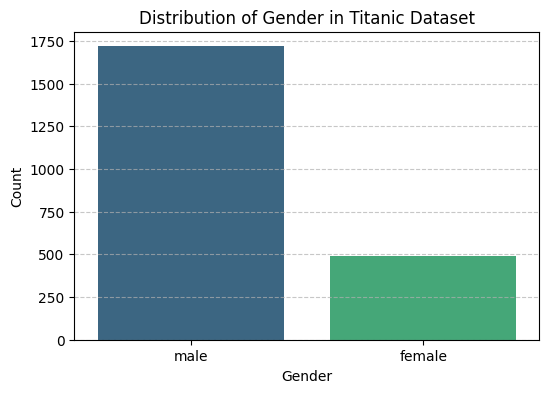

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=titanic, x='gender', hue='gender', legend=False, palette='viridis')
plt.title('Distribution of Gender in Titanic Dataset')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

I like that it clearly shows the count for each category (male and female), making it easy to compare their proportions.


However, a feature I don't like, is the lack of percentage labels on the bars. While the counts are clear, showing percentages would provide a quicker and more direct understanding of the distribution.

2\. Now click on the "generate" with AI link, or the Gemini button. Write a prompt to reproduce some of your analysis from earlier in this notebook. You can copy and paste one of the questions, or you can try writing your own prompt. Run the code and examine the results. How successful was it?

In [ ]:
# AI Prompt: Using the 'titanic' DataFrame, create a new column called 'new_country'.
# Map the existing 'country' column such that 'United States' remains 'United States',
# 'England', 'Scotland', 'Wales', 'Ireland', and 'Northern Ireland' all map to 'United Kingdom',
# and all other countries map to 'Other'. After creating the column, display the value counts for 'new_country'.

titanic["new_country"] = titanic["country"].map({
    "United States":"United States",
    "England":"United Kingdom",
    "Scotland":"United Kingdom",
    "Wales":"United Kingdom",
    "Ireland":"United Kingdom",
    "Northern Ireland": "United Kingdom"
}).fillna("Other")

titanic["new_country"].value_counts()

,count
new_country,
United Kingdom,1339
Other,604
United States,264


It was successful, the results matched what I did and seems to be correct.